## Описание проекта dream_project

### Цель проекта

Цель проекта — исследовать связь между характеристиками сна, образом жизни и состоянием человека в течение предыдущего дня и вероятностью запоминания сновидения на следующее утро. Дополнительно среди записей с запомнившимся сном рассматривается вероятность сообщения о цветном сне. Единицей наблюдения является запись об одной ночи одного участника. 

### Задачи проекта
1) Разработать анкету для ежедневного сбора данных о сне, образе жизни и состоянии участников.
2) Собрать данные у участников в течение нескольких последовательных дней.
3) Загрузить полученные данные в Python и привести их к единому формату.
4) Провести предварительную проверку качества данных:
- определить пропущенные значения;
- проверить дубликаты;
- проверить типы данных;
- выявить некорректные и потенциально невозможные значения;
- проверить полноту наблюдений по каждому участнику.
5) Выполнить предварительную обработку данных:
- преобразовать даты и время;
- преобразовать категориальные и бинарные признаки;
- рассчитать продолжительность сна;
- создать необходимые дополнительные признаки.
6) Провести исследовательский анализ данных (EDA):
- изучить распределения признаков;
- оценить распределение целевой переменной;
- сравнить признаки для наблюдений с запомненным и незапомненным сновидением;
- исследовать взаимосвязи между количественными признаками;
- проанализировать потенциальные выбросы.
7) Изучить структуру собранных данных и определить особенности повторных наблюдений за одними и теми же участниками.
8) Определить, какие признаки потенциально могут быть связаны с запоминанием сновидений, не интерпретируя наблюдаемые различия как причинно-следственные связи.
9) На следующем этапе использовать выявленную структуру данных при построении и оценке моделей машинного обучения.

### Гипотеза
Характеристики сна, режима дня и субъективного состояния участника могут быть связаны с вероятностью запоминания сновидения на следующее утро.

*Проект имеет учебный характер, использует небольшую выборку с повторными измерениями и не предназначен для медицинских рекомендаций.*

## Загрузка данных

### Импорт библиотек

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

### Чтение исходного csv и первичный просмотр данных

In [2]:
primary_df = pd.read_csv("dream.csv", usecols=list(range(1, 22)), header=0, names=["nick",
                                                                 "age",
                                                                 "sex", 
                                                                 "agreement", 
                                                                 "date",
                                                                 "fall_asleep",
                                                                 "wake_up", 
                                                                 "sleep_quality", 
                                                                 "awakenings", 
                                                                 "dream_remembered", 
                                                                 "dream_colored", 
                                                                 "amount_of_coffee", 
                                                                 "amount_of_coffee_after16",
                                                                 "alcohol",
                                                                 "strong_emotions",
                                                                 "stress_level",
                                                                 "hours_of_physical_activity",
                                                                 "daytime_sleep",
                                                                 "food_before_bed",
                                                                 "screen_time",
                                                                 "screen_before_bed",
                                                                 ])
primary_df.head(5)

,nick,age,sex,agreement,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_remembered,...,amount_of_coffee,amount_of_coffee_after16,alcohol,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed
0,OLKA75,45 лет и более,Женский,Да,13.09.2026,23:30:00,6:45:00,3,3,Да,...,1,0,Да,Нет,4,2,Да,Нет,3,Да
1,Zverskiyponos67,до 18 лет,Женский,Да,13.09.2026,2:00:00,10:00:00,3,1,Нет,...,1,0,Нет,Нет,5,0,Нет,Нет,8,Нет
2,Kreeper,от 18 до 30 лет,Женский,Да,13.09.2026,0:00:00,8:13:00,4,0,Нет,...,0,0,Нет,Нет,2,4,Нет,Нет,8,Да
3,Tukiceja,45 лет и более,Мужской,Да,13.09.2026,23:00:00,6:20:00,3,3,Нет,...,1,0,Да,Нет,2,3,Да,Нет,3,Да
4,TihiyOmut,от 18 до 30 лет,Мужской,Да,13.09.2026,3:00:00,10:25:00,5,0,Да,...,10,4,Да,Да,2,1,Нет,Да,3,Да


Значение столбцов:
- id - ник пользователей
- age - возраст
- sex - пол
- agreement - соглашение на обработку персональных даных
- date - дата заполнения
- fall_asleep - время засыпания
- wake_up - время пробуждения
- sleep_quality - оценка качества сна (1-5)
- awakenings - количество пробуждений ночью (1-10)
- dream_remembered - запомнился ли сон (Да/Нет)
- dream_colored - цвет сна (Цветной/Чёрно-белый/Точно не могу сказать)
- amount_of_coffee - количество чашек кофе (0-10)
- amount_of_coffee_after16 - количество чашек кофе после 16 (0-10)
- alcohol - употребление алкоголя (Да/Нет)
- strong_emotions - сильные эмоции (Да/Нет)
- stress_level - уровень стресса (1-10)
- hours_of_physical_activity - часы физической активности (0-10)
- daytime_sleep - сон днём (Да/Нет)
- food_before_bed - еда перед сном (Да/Нет)
- screen_time - экранное время за день (0-10)
- screen_before_bed - экран перед сном (Да/Нет)

Два дополнительных признака были исключены из основной версии датасета, поскольку они были добавлены после начала сбора, имеют значительную долю пропусков. Их влияние не исследуется в рамках данной версии проекта.

In [3]:
print(f"Размер dataframe: {primary_df.shape}")

Размер dataframe: (421, 21)


In [4]:
primary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   nick                        421 non-null    str  
 1   age                         421 non-null    str  
 2   sex                         421 non-null    str  
 3   agreement                   421 non-null    str  
 4   date                        421 non-null    str  
 5   fall_asleep                 421 non-null    str  
 6   wake_up                     421 non-null    str  
 7   sleep_quality               421 non-null    int64
 8   awakenings                  421 non-null    int64
 9   dream_remembered            421 non-null    str  
 10  dream_colored               187 non-null    str  
 11  amount_of_coffee            421 non-null    int64
 12  amount_of_coffee_after16    421 non-null    int64
 13  alcohol                     421 non-null    str  
 14  strong_emotions      

## Предварительная обработка данных

In [5]:
df = primary_df.copy()

### Преобразование даты и времени

In [6]:
# Дата
df["date"] = pd.to_datetime(df["date"])

# Время
df["wake_up"] = pd.to_timedelta(df["wake_up"])
df["fall_asleep"] = pd.to_timedelta(df["fall_asleep"])

C:\Users\Ilay\AppData\Local\Temp\ipykernel_15040\2717975209.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


### Преобразование категориальных признаков

In [7]:
# Категориальные колонки
df["dream_colored"] = df["dream_colored"].map({"В основном цветное": "color", "В основном чёрно-белое": "black-white", "Точно не могу сказать": "not_defined"})
categorial_cols = ["dream_colored"]
df[categorial_cols] = df[categorial_cols].astype("category")

age_ordered = ["до 18 лет", "от 18 до 30 лет", "от 30 до 45  лет", "45 лет и более"]
df["age"] = pd.Categorical(df["age"], categories=age_ordered, ordered=True)

Все категориальные значения были предварительно ограничены вариантами Google Forms. На этапе контроля проверено, что после импорта присутствуют только ожидаемые категории.

### Преобразование бинарных признаков

In [8]:
# Кодировка и преобразование в числовые
df["sex"] = df["sex"].map({"Мужской": 0, "Женский": 1})

binar_dict = {"Нет": 0, "Да": 1}
binary_cols = ["dream_remembered", "alcohol", "daytime_sleep", "food_before_bed", "strong_emotions", "screen_before_bed"]
for col in binary_cols:
    df[col] = df[col].map(binar_dict)
    
for col in df.columns:
    if "int" in str(df[col].dtype):
        df[col] = pd.to_numeric(df[col], downcast="integer")

|Признак|Кодировка|Значение|
|-------|---------|--------|
|sex|0|Мужской пол|
|sex|1|Женский пол|
|dream_remembered, alcohol, daytime_sleep, food_before_bed, strong_emotions, screen_before_bed|0|Нет|
|dream_remembered, alcohol, daytime_sleep, food_before_bed, strong_emotions, screen_before_bed|1|Да|

### Расчёт продолжительности сна

In [9]:
def calc_sleep_hours(df):
    diff = df["wake_up"] - df["fall_asleep"]
    mask = diff < pd.Timedelta(0)
    diff.loc[mask] += pd.Timedelta(days=1)

    df["sleep_duration"] = diff
    df["sleep_hours"] = diff.dt.total_seconds() / 3600
    
    return df

df = calc_sleep_hours(df)

## Проверка качества данных

In [10]:
# info после обработки столбцов
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype          
---  ------                      --------------  -----          
 0   nick                        421 non-null    str            
 1   age                         421 non-null    category       
 2   sex                         421 non-null    int8           
 3   agreement                   421 non-null    str            
 4   date                        421 non-null    datetime64[us] 
 5   fall_asleep                 421 non-null    timedelta64[us]
 6   wake_up                     421 non-null    timedelta64[us]
 7   sleep_quality               421 non-null    int8           
 8   awakenings                  421 non-null    int8           
 9   dream_remembered            421 non-null    int8           
 10  dream_colored               187 non-null    category       
 11  amount_of_coffee            421 non-null    int8        

In [11]:
print("Пропусков после бинаризации:", df[binary_cols].isna().sum().sum())

Пропусков после бинаризации: 0


In [12]:
df.isna().sum()

nick                            0
age                             0
sex                             0
agreement                       0
date                            0
fall_asleep                     0
wake_up                         0
sleep_quality                   0
awakenings                      0
dream_remembered                0
dream_colored                 234
amount_of_coffee                0
amount_of_coffee_after16        0
alcohol                         0
strong_emotions                 0
stress_level                    0
hours_of_physical_activity      0
daytime_sleep                   0
food_before_bed                 0
screen_time                     0
screen_before_bed               0
sleep_duration                  0
sleep_hours                     0
dtype: int64

Пропуски найдены только в столбце dream_colored: 234. Данные пропуски являются не случайными, а техническими, потому что в этот день пользователи не видели сна ночью.

dream_remembered=="Нет" --> dream_colored=="NaN"

In [13]:
without_dream = df[df["dream_remembered"]== 0]["dream_remembered"].count()
print(f"Количество ответов людей, не видивших сон: {without_dream}")

Количество ответов людей, не видивших сон: 234


In [14]:
df.describe()

,sex,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_remembered,amount_of_coffee,amount_of_coffee_after16,alcohol,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed,sleep_duration,sleep_hours
count,421.000000,421,421,421,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421,421.000000
mean,0.646081,2026-09-18 15:30:21.377672,0 days 09:48:17.529691,0 days 07:51:21.092636,3.745843,1.268409,0.444181,0.790974,0.263658,0.097387,0.451306,3.634204,2.524941,0.128266,0.460808,5.529691,0.909739,0 days 07:27:25.795724,7.457165
min,0.000000,2026-09-13 00:00:00,0 days 00:00:00,0 days 00:09:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0 days 01:00:00,1.000000
25%,0.000000,2026-09-16 00:00:00,0 days 01:00:00,0 days 06:30:00,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,3.000000,1.000000,0 days 06:20:00,6.333333
50%,1.000000,2026-09-19 00:00:00,0 days 02:50:00,0 days 07:40:00,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,5.000000,1.000000,0 days 07:23:00,7.383333
75%,1.000000,2026-09-22 00:00:00,0 days 23:00:00,0 days 09:00:00,5.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,0.000000,1.000000,8.000000,1.000000,0 days 08:30:00,8.500000
max,1.000000,2026-09-26 00:00:00,0 days 23:59:00,0 days 16:12:00,5.000000,10.000000,1.000000,10.000000,4.000000,1.000000,1.000000,10.000000,10.000000,1.000000,1.000000,10.000000,1.000000,0 days 23:14:00,23.233333
std,0.478753,NaN,0 days 10:23:36.991220,0 days 01:54:55.151073,1.068828,1.653762,0.497466,1.118679,0.568486,0.296837,0.498215,2.294749,1.997015,0.334784,0.499055,2.692529,0.286897,0 days 02:13:55.268961,2.232019


В ряде количественных признаков среднее значение превышает медиану, что может указывать на правостороннюю асимметрию распределения. Некоторые экстремальные значения требуют дополнительной проверки.

In [15]:
# Дубликаты
df.duplicated().sum()

np.int64(0)

На стадии проверки качества данных дупликаты не были обнаружены

In [16]:
# Уникальные значения
df.nunique()

nick                           53
age                             4
sex                             2
agreement                       1
date                           14
fall_asleep                   117
wake_up                       118
sleep_quality                   5
awakenings                     11
dream_remembered                2
dream_colored                   3
amount_of_coffee                6
amount_of_coffee_after16        4
alcohol                         2
strong_emotions                 2
stress_level                   10
hours_of_physical_activity     10
daytime_sleep                   2
food_before_bed                 2
screen_time                    11
screen_before_bed               2
sleep_duration                150
sleep_hours                   150
dtype: int64

In [17]:
# Все значения столбца "agreement" содержат только ответ "Да"
df = df.drop(["agreement"], axis=1)

Столбец agreement удалён, поскольку все участники дали одинаковый ответ и признак не содержит вариативности.

## Первичный анализ выборки

### Анализ количества участников и валидность псевдонимов

In [18]:
print(f"Количество уникальных пользователей: {df["nick"].nunique()}")

Количество уникальных пользователей: 53


In [19]:
df["nick"].unique()

<StringArray>
[          'OLKA75',  'Zverskiyponos67',          'Kreeper',
         'Tukiceja',        'TihiyOmut',         'aboba777',
      'SLEEP_LOVER',            'hewwa',            'Прага',
              'Оно',           'nejnej',         'krasotka',
            'FOX07',             'Leva',         'Удача777',
          '1515net',      'Птицадивная',       'nikita_pdf',
    'Enemyofdeath ',        'aquamana ',          'GRASS42',
          'Маркул ',       'Константин',           'Наташа',
              'son',    'Питер Паркер ',       'silverain ',
 'GangsterMarmilad',         'WH1teM4N',            'Настя',
          'Rinasvm',           'Deston',            'груша',
        'даринкинс',     'Enemyofdeath',               'N1',
           'Fit345',        'Tukiceja ',     'Питер Паркер',
         'aquamana',           'Маркул',     'Птицадивная ',
        'silverain',       'TihiyOmut ',          'Pandora',
        'WH1teM4N ',      'nikita_pdf ',       'Sunflower ',
        'S

Обнаружены ошибки с наличием пробелов в конце, начале и середине псевдонима

In [20]:
# Очистим лишние пробелы
df["nick"] = df["nick"].str.replace(" ", "")
print(f"Количество уникальных участников: {df["nick"].nunique()}")

Количество уникальных участников: 38


### Количество наблюдений на каждого участника опроса

In [21]:
# Установим для каждого пользователя уникальный participant_id
df["participant_id"] = df.groupby(by=["nick"])["nick"].transform("ngroup") + 1

df = df.drop("nick", axis=1)

In [22]:
person_day = df.groupby(by=["participant_id"]).size().reset_index(name='count')
person_day

,participant_id,count
0,1,12
1,2,4
2,3,12
3,4,12
4,5,11
5,6,12
6,7,12
7,8,12
8,9,12
9,10,7


In [23]:
print(f"Количество участников, проходивших опрос все 12 дней: {len(person_day[person_day["count"] >= 12])}")

Количество участников, проходивших опрос все 12 дней: 26


### Распределение возрастных групп

In [24]:
df[["participant_id", "age"]].drop_duplicates()["age"].value_counts(normalize=True)

age
от 18 до 30 лет     0.692308
45 лет и более      0.205128
до 18 лет           0.076923
от 30 до 45  лет    0.025641
Name: proportion, dtype: float64

Возраст 69% в группе "от 18 до 30 лет", признак мало вариативен и почти константа

### Распределение пола

In [25]:
df[["participant_id", "sex"]].drop_duplicates()["sex"].value_counts(normalize=True)

sex
1    0.657895
0    0.342105
Name: proportion, dtype: float64

Доля женского пола (65.7%), проходившего опрос, значительно больше мужского (34,2%)

### Распределение целевой переменной `dream_remembered`

In [26]:
df["dream_remembered"].value_counts(normalize=True)

dream_remembered
0    0.555819
1    0.444181
Name: proportion, dtype: float64

## Исследовательский анализ данных (EDA)

### Распределение и анализ переменной dream_colored

In [27]:
df["dream_colored"].value_counts(normalize=True)

dream_colored
color          0.802139
not_defined    0.133690
black-white    0.064171
Name: proportion, dtype: float64

In [28]:
dream_color_for_ages = df.groupby(by="age")["dream_colored"].value_counts().reset_index(name="count")
pivot_dream_color = dream_color_for_ages.pivot(index="age", columns="dream_colored", values="count")
pivot_dream_color

dream_colored,black-white,color,not_defined
age,,,
до 18 лет,0,4,0
от 18 до 30 лет,2,112,11
от 30 до 45 лет,0,7,0
45 лет и более,10,27,14


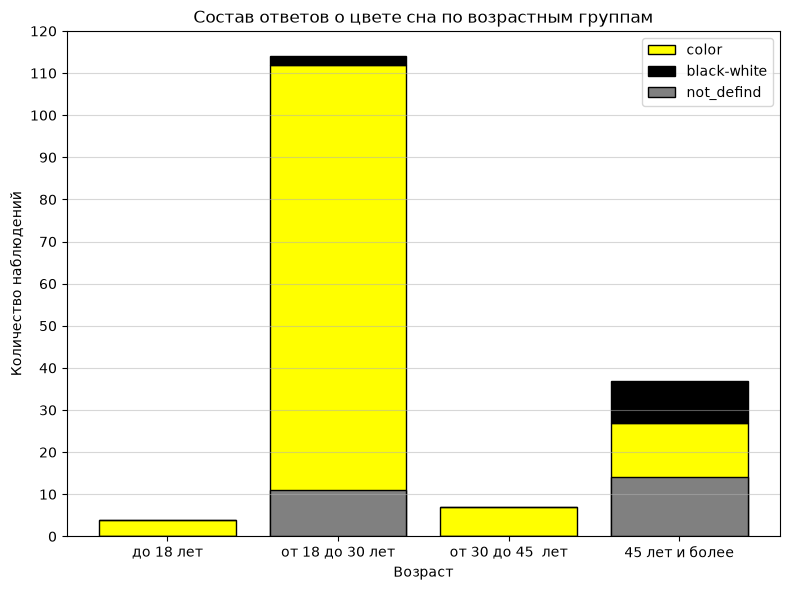

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(pivot_dream_color.index, pivot_dream_color["color"], color="yellow", edgecolor="black")
ax.bar(pivot_dream_color.index, pivot_dream_color["black-white"], bottom=pivot_dream_color["color"], color="black", edgecolor="black")
ax.bar(pivot_dream_color.index, pivot_dream_color["not_defined"], color="gray", edgecolor="black")

ax.set_title("Cостав ответов о цвете сна по возрастным группам")
ax.set_xlabel("Возраст")
ax.set_ylabel("Количество наблюдений")

ax.set_yticks(range(0, 130, 10))

ax.grid(True, axis="y", alpha=0.5)

ax.legend(labels=["color", "black-white", "not_defind"])

plt.tight_layout()
plt.show()

Среди наблюдений с запомнившимся сном и определённым ответом о цвете доля цветных ответов составила 80%. В имеющейся выборке ответы о чёрно-белых снах чаще встречались у участников старшей возрастной группы. Из-за малого количества участников в этой группе нельзя делать устойчивый вывод о связи возраста и цветности снов.

### Доля запомненных сновидений по участникам

In [30]:
print("Доля запоминания сна у каждого участника, %")
shape_remembered = (df.groupby(by="participant_id")["dream_remembered"].mean() * 100).sort_values().reset_index(name="shape")
shape_remembered

Доля запоминания сна у каждого участника, %


,participant_id,shape
0,5,0.000000
1,12,0.000000
2,1,16.666667
3,21,16.666667
4,28,16.666667
5,38,16.666667
6,20,18.181818
7,19,25.000000
8,32,25.000000
9,2,25.000000


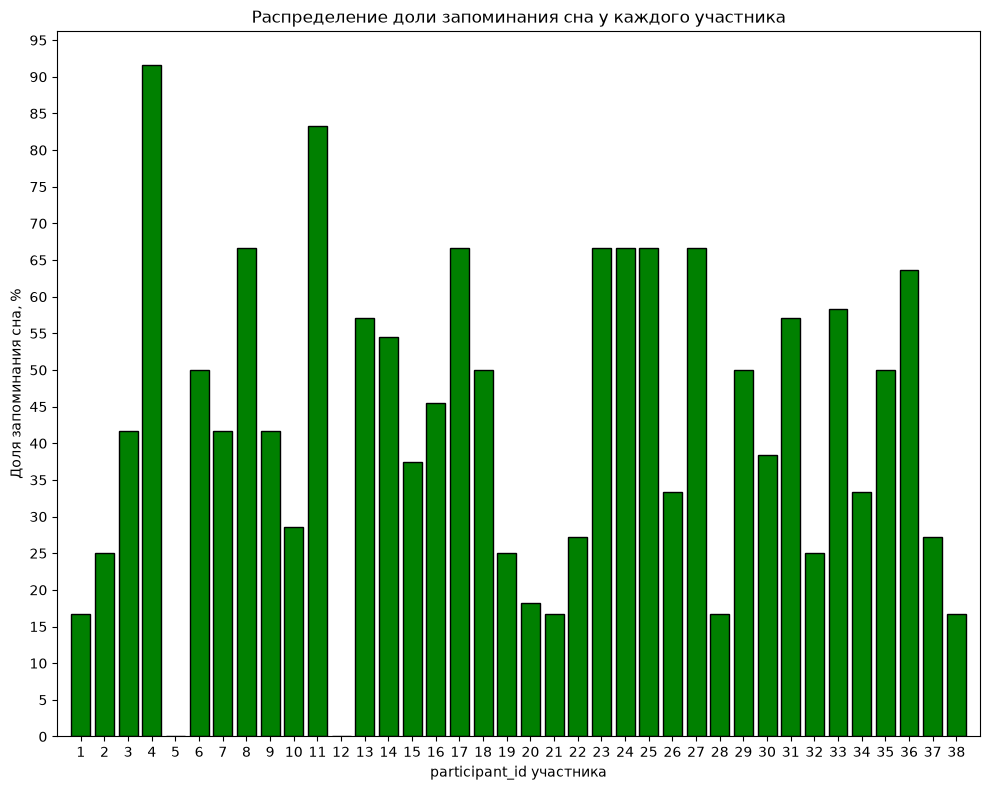

In [31]:
shape_remembered = shape_remembered.sort_values(by="participant_id")

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(shape_remembered["participant_id"], shape_remembered["shape"], color="green", edgecolor="black")

ax.set_title("Распределение доли запоминания сна у каждого участника")
ax.set_xlabel("participant_id участника")
ax.set_ylabel("Доля запоминания сна, %")

ax.set_xticks(range(1, len(shape_remembered["participant_id"]) + 1))
ax.set_xlim(0, len(shape_remembered["participant_id"]) + 1)

ax.set_yticks(range(0, 100, 5))

plt.tight_layout()
plt.show()

In [32]:
print(f"Максимальный процент запоминания снов у участника: {shape_remembered.max().round(1)}%")
print(f"Минимальный процент запоминания снов у участника: {shape_remembered.min().round(1)}%")

Максимальный процент запоминания снов у участника: participant_id    38.0
shape             91.7
dtype: float64%
Минимальный процент запоминания снов у участника: participant_id    1.0
shape             0.0
dtype: float64%


### Построение диаграммы boxplot для целевой переменной `dream_remembered` по всем наблюдениям.

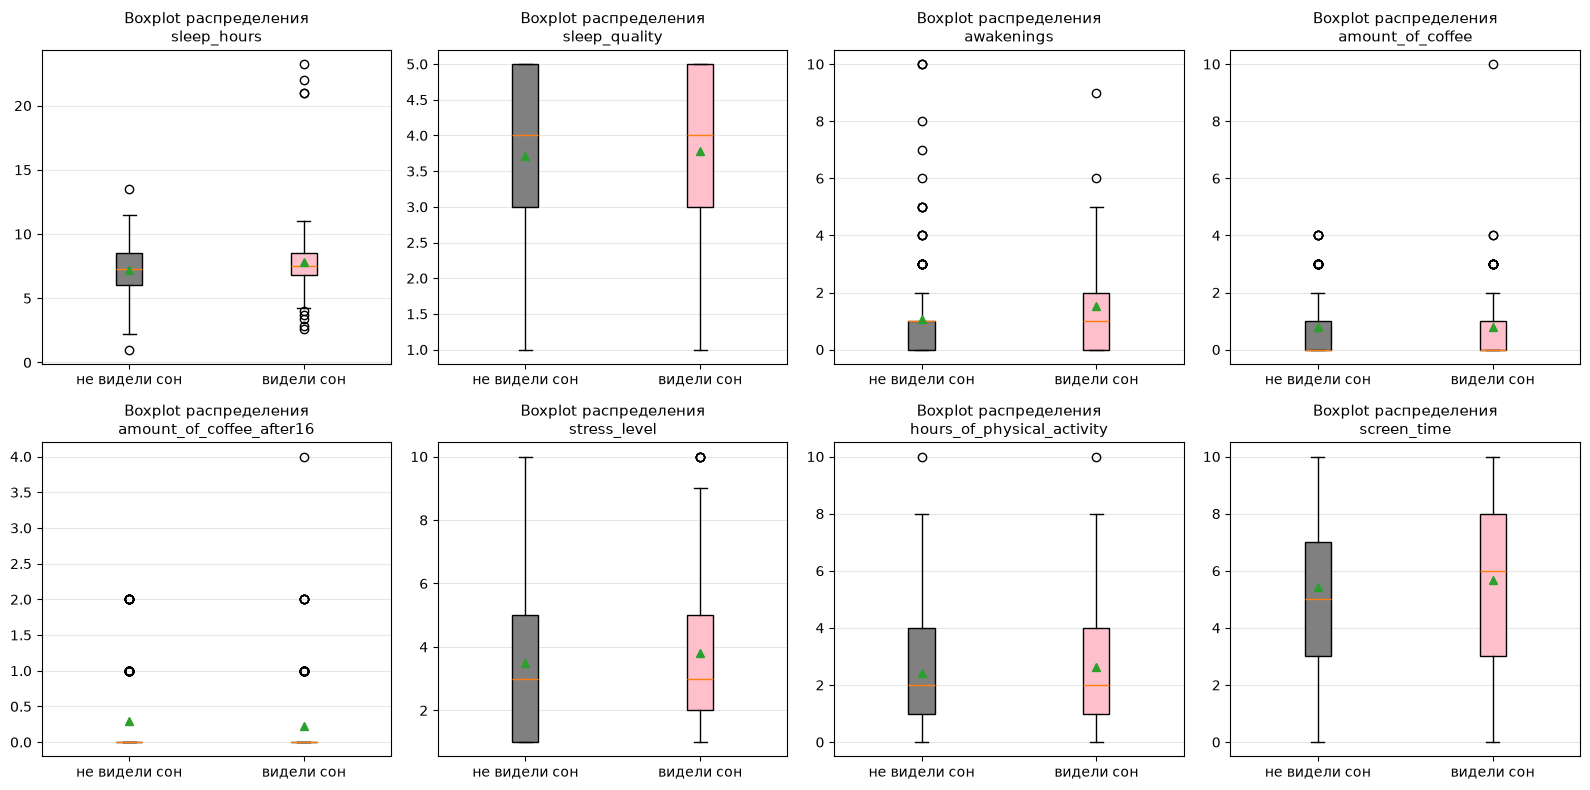

In [33]:
boxplot_cols = ['sleep_hours', 'sleep_quality', 'awakenings', 'amount_of_coffee', 'amount_of_coffee_after16', 'stress_level', 'hours_of_physical_activity', 'screen_time']

n = len(boxplot_cols)

fig, axes =  plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))

for ax, i in zip(axes.flatten(), boxplot_cols):

    group_0 = df[df["dream_remembered"] == 0][i].values
    group_1 = df[df["dream_remembered"] == 1][i].values

    bp = ax.boxplot([group_0, group_1], tick_labels=["не видели сон", "видели сон"], showmeans=True, patch_artist=True)

    ax.set_title(f"Boxplot распределения\n{i}", fontsize=11)

    ax.grid(True, alpha=0.3, axis="y")

    bp["boxes"][0].set_facecolor("gray")
    bp["boxes"][1].set_facecolor("pink")

plt.tight_layout()
plt.show()

- sleep hours: Медиана у видевших сон немного выше - примерно 7,5 часа против 7–7,2 часа. Есть выбросы около 21–23 часов; их стоит проверить в исходных данных.
- awakenings: У видевших и невидевших сон медиана около 1 пробуждения. Разброс большой, много выбросов сверху, у людей не видевших сон
- stress_level: Медиана в обеих группах около 3. У видевших сон среднее выглядит немного выше, но распределения существенно перекрываются.
- screen_time: Медиана у видевших сон около 6 часов, у не видевших — около 5. При этом разброс в обеих группах широк
- в графиках sleep_quality, amount_of_coffe(_after16), hours_of_physical_activity между видевшими и невидевшими сон различия близки к минимуму

### Построение столбчатой ​​диаграммы для целевой переменной `dream_remembered` для бинарных признаков

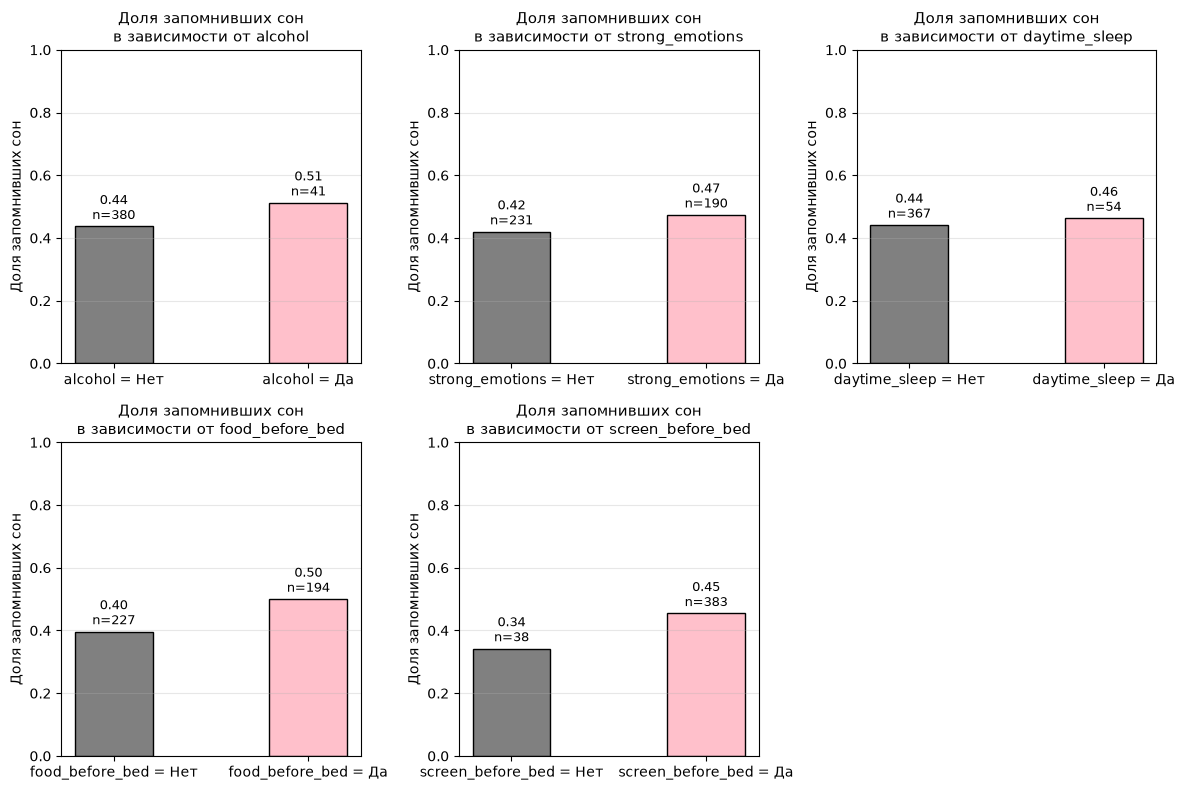

In [34]:
barchart_cols = ["alcohol", "strong_emotions", "daytime_sleep", "food_before_bed", "screen_before_bed"]
n = len(barchart_cols)

fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))

for ax, col in zip(axes.flatten(), barchart_cols):
    grouped = df.groupby(col)["dream_remembered"].agg(["mean", "count"])

    labels = [f"{col} = Нет", f"{col} = Да"]

    bars = ax.bar(labels, grouped["mean"], color=["gray", "pink"], width=0.4, edgecolor="black")

    for bar, mean_val, count_val in zip(bars, grouped["mean"], grouped["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{mean_val:.2f}\nn={count_val}",
                ha="center", va="bottom", fontsize=9)

    ax.set_title(f"Доля запомнивших сон\nв зависимости от {col}", fontsize=11)
    ax.set_ylabel("Доля запомнивших сон")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis="y")

for ax in axes.flatten()[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

- alcohol: Доля несколько выше среди видевших сон
- strong_emotions: Разница незначительная
- daytime_sleep: Практически одинаковые доли
- food_before_bed: Разница около 10 процентных пунктов — одна из наиболее заметных на этих графиках
- screen_before_bed: Разница около 11 процентных пунктов — также одна из наиболее заметных

### Проверка выбросов и валидность данных для sleep_hours

In [35]:
# Проверка нижней границы выбросов
df[df["sleep_hours"] < 3]

,age,sex,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_remembered,dream_colored,amount_of_coffee,...,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed,sleep_duration,sleep_hours,participant_id
25,от 18 до 30 лет,0,2026-09-13,0 days 05:00:00,0 days 07:30:00,2,0,0,NaN,0,...,1,3,7,0,1,2,0,0 days 02:30:00,2.500000,33
100,от 18 до 30 лет,1,2026-09-16,0 days 04:10:00,0 days 07:00:00,3,0,1,color,1,...,1,7,1,0,0,5,1,0 days 02:50:00,2.833333,37
101,от 18 до 30 лет,1,2026-09-16,0 days 04:52:00,0 days 07:34:00,2,0,0,NaN,1,...,1,1,1,0,0,5,1,0 days 02:42:00,2.700000,38
167,45 лет и более,1,2026-09-17,0 days 02:00:00,0 days 03:00:00,1,10,0,NaN,3,...,1,10,2,0,1,3,1,0 days 01:00:00,1.000000,36
232,45 лет и более,1,2026-09-19,0 days 00:01:00,0 days 02:36:00,3,2,1,black-white,3,...,0,3,6,0,0,3,1,0 days 02:35:00,2.583333,31
274,от 18 до 30 лет,1,2026-09-21,0 days 05:50:00,0 days 08:20:00,2,0,0,NaN,1,...,1,7,2,0,0,8,1,0 days 02:30:00,2.500000,37
281,от 18 до 30 лет,1,2026-09-21,0 days 04:57:00,0 days 07:50:00,3,0,0,NaN,2,...,0,1,0,0,0,4,1,0 days 02:53:00,2.883333,38
314,от 18 до 30 лет,1,2026-09-22,0 days 04:30:00,0 days 06:45:00,1,10,0,NaN,1,...,1,7,3,0,1,4,1,0 days 02:15:00,2.250000,15
384,от 18 до 30 лет,0,2026-09-24,0 days 05:00:00,0 days 07:50:00,1,0,0,NaN,0,...,0,7,3,0,1,10,1,0 days 02:50:00,2.833333,27


Данные по нижней границе выбросов корректны, но точные предположения о их достоверности гарантировать невозможно

In [36]:
# Проверка верхней границы выбросов
Q3 = df["sleep_hours"].describe()["75%"]
Q1 = df["sleep_hours"].describe()["25%"]
IQR = Q3- Q1
emission_limit = Q3 + 1.5 * IQR

print(f"Граница верхних выбросов: {emission_limit}")

Граница верхних выбросов: 11.75


In [37]:
df[df["sleep_hours"] > emission_limit][["participant_id", "fall_asleep", "wake_up", "sleep_hours"]]

,participant_id,fall_asleep,wake_up,sleep_hours
16,35,0 days 10:30:00,0 days 07:30:00,21.000000
39,35,0 days 10:25:00,0 days 07:26:00,21.016667
53,33,0 days 12:00:00,0 days 10:00:00,22.000000
230,3,0 days 00:55:00,0 days 00:09:00,23.233333
358,16,0 days 21:00:00,0 days 10:32:00,13.533333


- В первых 3-х записях - ошибка записи формата времени (12 часовой вместо 24 часового формата)
- В 4 записи некорректно отмечено время подъёма - (вместо 09:00 00:09)
- В последней записи выброс является корректным

*Так как невалидны только 4 записи, исправление корректно будет проводить вручную*

In [38]:
# Исправление первых 3-х наблюдений
df.loc[[16, 39], "fall_asleep"] += pd.Timedelta(hours=12)

df.loc[53, "fall_asleep"] -= pd.Timedelta(hours=12)

In [39]:
# Исправление 4 наблюдения
df.loc[230, "wake_up"] = pd.to_timedelta("09:00:00")

In [40]:
df = calc_sleep_hours(df)

#Проверка
df[df["sleep_hours"] > emission_limit][["participant_id", "fall_asleep", "wake_up", "sleep_hours"]]

,participant_id,fall_asleep,wake_up,sleep_hours
358,16,0 days 21:00:00,0 days 10:32:00,13.533333


In [41]:
df["sleep_hours"].describe()

count    421.000000
mean       7.335669
std        1.739053
min        1.000000
25%        6.333333
50%        7.383333
75%        8.500000
max       13.533333
Name: sleep_hours, dtype: float64

Исправление данных повело к исключению из выбросов. Теперь по верхней границе только 1 корректный выброс

### Корреляционный анализ

In [42]:
num_cols = df.select_dtypes(include=[np.number], exclude=[np.timedelta64])
num_cols = num_cols.drop("participant_id", axis=1)

In [43]:
corr_matrix = num_cols.corr()

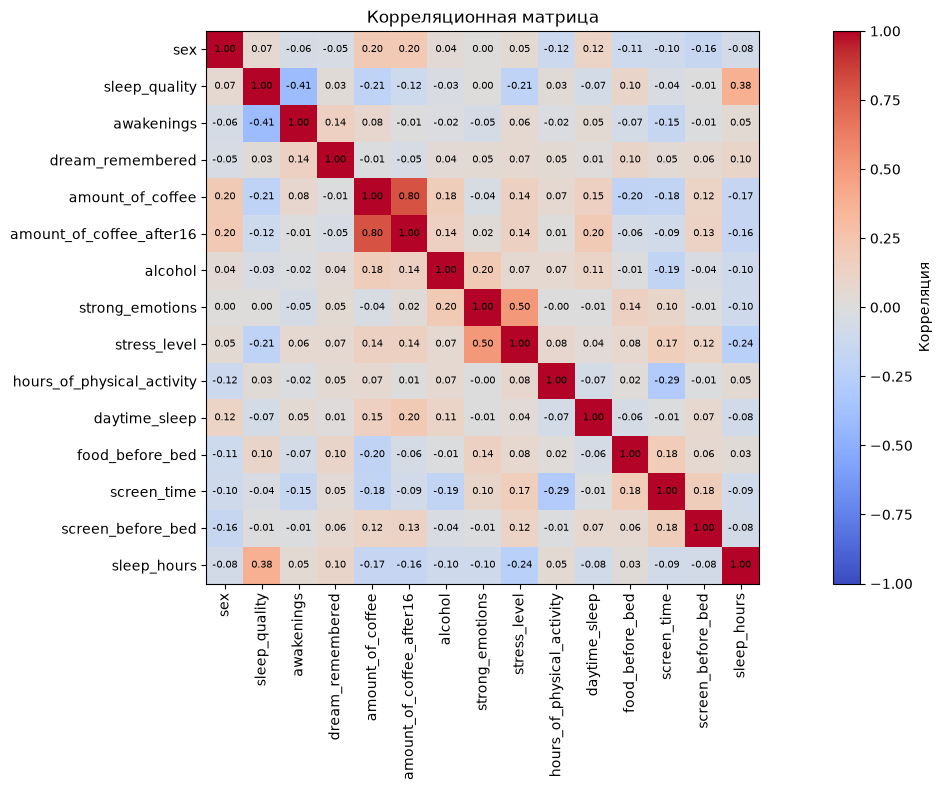

In [44]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title("Корреляционная матрица")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns, fontsize=10, rotation=0)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, fontsize=10, rotation=90)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

В рассматриваемых числовых признаках не наблюдается заметной линейной ассоциации с таргетом. Это не исключает нелинейные зависимости, взаимодействия или влияние участника.

### Вывод по результатам общего EDA

На этапе первичного исследовательского анализа были рассмотрены распределения основных признаков и их различия между наблюдениями, в которых участник запомнил сон, и наблюдениями без воспоминания о сне.

В целом выраженных различий между двумя группами по большинству исследуемых признаков не обнаружено. При этом наблюдаются отдельные тенденции: в группе с воспоминанием о сне медианная продолжительность сна несколько выше, а также заметны небольшие различия по времени за экраном, употреблению алкоголя, приёму пищи перед сном и использованию экрана перед сном. Однако этих наблюдений недостаточно для вывода о наличии причинно-следственной связи.

Корреляционный анализ также не выявил выраженных линейных связей между числовыми признаками и целевой переменной. Это не исключает наличия нелинейных зависимостей или взаимодействия нескольких факторов.

Дополнительной особенностью набора данных является его повторная структура: один участник представлен несколькими наблюдениями за разные дни. Поэтому строки датасета нельзя считать полностью независимыми наблюдениями. Это необходимо учитывать на следующих этапах анализа и при построении моделей.

Таким образом, общий EDA позволил получить представление о структуре данных, распределениях признаков и возможных направлениях дальнейшего анализа. Следующим этапом является анализ панельной структуры данных, после чего можно перейти к подготовке признаков и построению моделей классификации для прогнозирования вероятности запоминания сна.

## Панельная структура данных

### Формализация структуры данных

In [45]:
df = df.sort_values(["participant_id", "date"])
df["observation_number"] = df.groupby(by="participant_id").cumcount() + 1

df[["date", "observation_number"]].head(5)

,date,observation_number
15,2026-09-13,1
51,2026-09-14,2
82,2026-09-15,3
117,2026-09-16,4
144,2026-09-17,5


In [46]:
print("Доля пройденных дней опроса, %")
person_proportion = (person_day.value_counts(normalize=True, subset="count") * 100).reset_index(name="proportion")
person_proportion

Доля пройденных дней опроса, %


,count,proportion
0,12,60.526316
1,11,18.421053
2,7,5.263158
3,14,5.263158
4,4,2.631579
5,1,2.631579
6,8,2.631579
7,13,2.631579


In [47]:
print(f"Доля участников с полным циклом опроса (12 дней): {person_proportion[person_proportion["count"] >= 12]["proportion"].sum().round(2)}%")

Доля участников с полным циклом опроса (12 дней): 68.42%


In [48]:
n_obs = df.groupby("participant_id").size()
print(f"Количество участников с полным циклом наблюдений: {(n_obs >= 12).sum()}")

Количество участников с полным циклом наблюдений: 26


### Таблица балансировки панели

In [49]:
balance_table = pd.DataFrame({
    "Наблюдений на участника": n_obs.value_counts().sort_index(),
    "Доля участников, %": (n_obs.value_counts(normalize=True).sort_index() * 100).round(1)
}).reset_index().rename(columns={"index": "Количество наблюдений"})

balance_table

,Количество наблюдений,Наблюдений на участника,"Доля участников, %"
0,1,1,2.6
1,4,1,2.6
2,7,2,5.3
3,8,1,2.6
4,11,7,18.4
5,12,23,60.5
6,13,1,2.6
7,14,2,5.3


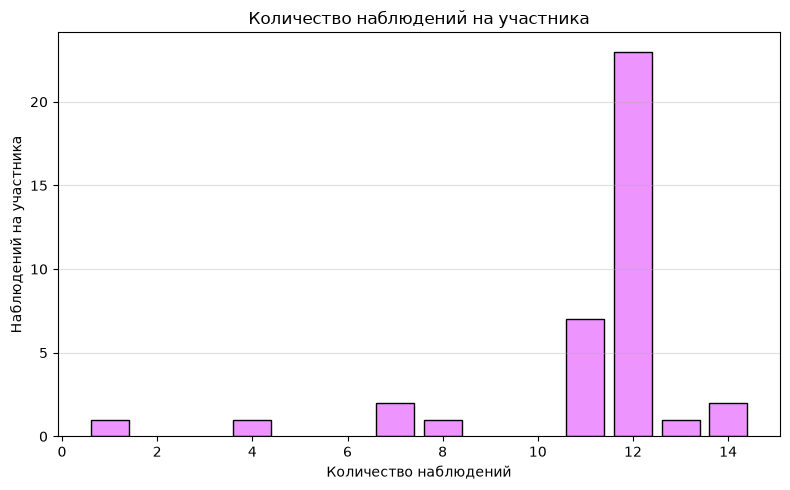

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(balance_table["Количество наблюдений"], balance_table["Наблюдений на участника"], edgecolor="black", color="#ee94ff")

ax.set_title("Количество наблюдений на участника")
ax.set_xlabel("Количество наблюдений")
ax.set_ylabel("Наблюдений на участника")

ax.grid(True, axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

### Статистика дат первого и последнего прохождения опроса и пропусков календарных дней

In [51]:
# 12 дней — запланированное количество наблюдений в дизайне исследования
date_range = df.groupby("participant_id")["date"].min().reset_index(name="first_date")
date_range["last_date"] = df.groupby("participant_id")["date"].transform("max")
date_range = date_range.set_index("participant_id")
date_range["actual_days"] = n_obs
date_range["missing_days"] = date_range["actual_days"].apply(lambda x: 12 - x if x <= 12 else 0)

date_range.head(5)

,first_date,last_date,actual_days,missing_days
participant_id,,,,
1,2026-09-13,2026-09-24,12,0
2,2026-09-14,2026-09-24,4,8
3,2026-09-13,2026-09-24,12,0
4,2026-09-13,2026-09-24,12,0
5,2026-09-14,2026-09-24,11,1


In [52]:
print(f"Среднее число пропущенных дней: {date_range["missing_days"].mean():.2f}")
print(f"Медианное число пропущенных дней: {date_range["missing_days"].median():.2f}")

print(f"Количество участников с пропусками: {date_range[date_range["missing_days"] > 0]["missing_days"].count()}")

Среднее число пропущенных дней: 1.05
Медианное число пропущенных дней: 0.00
Количество участников с пропусками: 12


### Просмотр людей с календарными разрывами

In [53]:
def count_calendar_gaps(group):
    dates = group["date"].sort_values()
    gaps = (dates.diff().dt.days > 1).sum()
    return gaps

calendar_gaps = df.groupby("participant_id").apply(count_calendar_gaps)
print(f"Участников с календарными разрывами: {(calendar_gaps > 0).sum()}")
print(f"Среднее число разрывов на участника: {calendar_gaps.mean():.2f}")

Участников с календарными разрывами: 7
Среднее число разрывов на участника: 0.24


In [54]:
# Удаляем участника с 1 наблюдением
df = df.groupby(by="participant_id").filter(lambda x: len(x) > 1)

### Описательная статистика по участникам

|Признак|Тип|Как анализировать|
|-------|---|-----------------|
|age	|Constant	|Только Between|
|sex	|Constant	|Только Between|
|sleep_hours	|Time-varying	|Within + Between|
|sleep_quality	|Time-varying	|Within + Between|
|awakenings	|Time-varying	|Within + Between|
|amount_of_coffee	|Time-varying	|Within + Between|
|amount_of_coffee_after16	|Time-varying	|Within + Between|
|stress_level	|Time-varying	|Within + Between|
|hours_of_physical_activity	|Time-varying	|Within + Between|
|screen_time	|Time-varying	|Within + Between|
|alcohol	|Time-varying	|Within + Between|
|strong_emotions	|Time-varying	|Within + Between|
|daytime_sleep	|Time-varying	|Within + Between|
|food_before_bed	|Time-varying	|Within + Between|
|screen_before_bed	|Time-varying	|Within + Between|
|dream_remembered	|Целевая	|Отдельно|

In [55]:
time_varying_cols = [
    "sleep_hours",
    "sleep_quality",
    "awakenings",
    "amount_of_coffee",
    "amount_of_coffee_after16",
    "stress_level",
    "hours_of_physical_activity",
    "screen_time",
    "alcohol",
    "strong_emotions",
    "daytime_sleep",
    "food_before_bed",
    "screen_before_bed"
]

between_within = pd.DataFrame(df[["participant_id", "observation_number"]])

for i in time_varying_cols:
    between_within[f"{i}_pmean"] = df.groupby(by="participant_id")[i].transform("mean")
    between_within[f"{i}_within"] = df[i] - between_within[f"{i}_pmean"]

between_within

,participant_id,observation_number,sleep_hours_pmean,sleep_hours_within,sleep_quality_pmean,sleep_quality_within,awakenings_pmean,awakenings_within,amount_of_coffee_pmean,amount_of_coffee_within,...,alcohol_pmean,alcohol_within,strong_emotions_pmean,strong_emotions_within,daytime_sleep_pmean,daytime_sleep_within,food_before_bed_pmean,food_before_bed_within,screen_before_bed_pmean,screen_before_bed_within
15,1,1,7.054167,3.695833,4.083333,-0.083333,0.666667,1.333333,0.000000,0.000000,...,0.083333,-0.083333,0.500000,0.500000,0.25,-0.25,0.166667,-0.166667,0.333333,-0.333333
51,1,2,7.054167,2.112500,4.083333,0.916667,0.666667,-0.666667,0.000000,0.000000,...,0.083333,-0.083333,0.500000,-0.500000,0.25,0.75,0.166667,0.833333,0.333333,0.666667
82,1,3,7.054167,-1.954167,4.083333,-0.083333,0.666667,0.333333,0.000000,0.000000,...,0.083333,-0.083333,0.500000,0.500000,0.25,-0.25,0.166667,-0.166667,0.333333,-0.333333
117,1,4,7.054167,-3.137500,4.083333,-0.083333,0.666667,-0.666667,0.000000,0.000000,...,0.083333,-0.083333,0.500000,0.500000,0.25,-0.25,0.166667,-0.166667,0.333333,-0.333333
144,1,5,7.054167,-0.620833,4.083333,-1.083333,0.666667,2.333333,0.000000,0.000000,...,0.083333,-0.083333,0.500000,-0.500000,0.25,0.75,0.166667,-0.166667,0.333333,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,38,8,5.891667,-3.008333,3.000000,0.000000,1.333333,-1.333333,1.666667,0.333333,...,0.250000,-0.250000,0.666667,-0.666667,0.50,-0.50,0.250000,-0.250000,1.000000,0.000000
313,38,9,5.891667,-0.975000,3.000000,-2.000000,1.333333,8.666667,1.666667,0.333333,...,0.250000,-0.250000,0.666667,0.333333,0.50,0.50,0.250000,0.750000,1.000000,0.000000
367,38,10,5.891667,-1.308333,3.000000,-1.000000,1.333333,-1.333333,1.666667,1.333333,...,0.250000,0.750000,0.666667,0.333333,0.50,-0.50,0.250000,-0.250000,1.000000,0.000000
405,38,11,5.891667,0.108333,3.000000,0.000000,1.333333,-0.333333,1.666667,0.333333,...,0.250000,0.750000,0.666667,0.333333,0.50,0.50,0.250000,-0.250000,1.000000,0.000000


In [56]:
with_in_cols = [col for col in between_within.columns if "_within" in col]

print("Проверка, что среднее _within признака для каждого участника примерно равна нулю:")
for col in with_in_cols:
    check = between_within.groupby("participant_id")[col].mean().sum().round(1)

    print(f"{col}: {np.abs(check)}")

Проверка, что среднее _within признака для каждого участника примерно равна нулю:
sleep_hours_within: 0.0
sleep_quality_within: 0.0
awakenings_within: 0.0
amount_of_coffee_within: 0.0
amount_of_coffee_after16_within: 0.0
stress_level_within: 0.0
hours_of_physical_activity_within: 0.0
screen_time_within: 0.0
alcohol_within: 0.0
strong_emotions_within: 0.0
daytime_sleep_within: 0.0
food_before_bed_within: 0.0
screen_before_bed_within: 0.0


### Визуализация межличностной декомпозиции (p_mean)

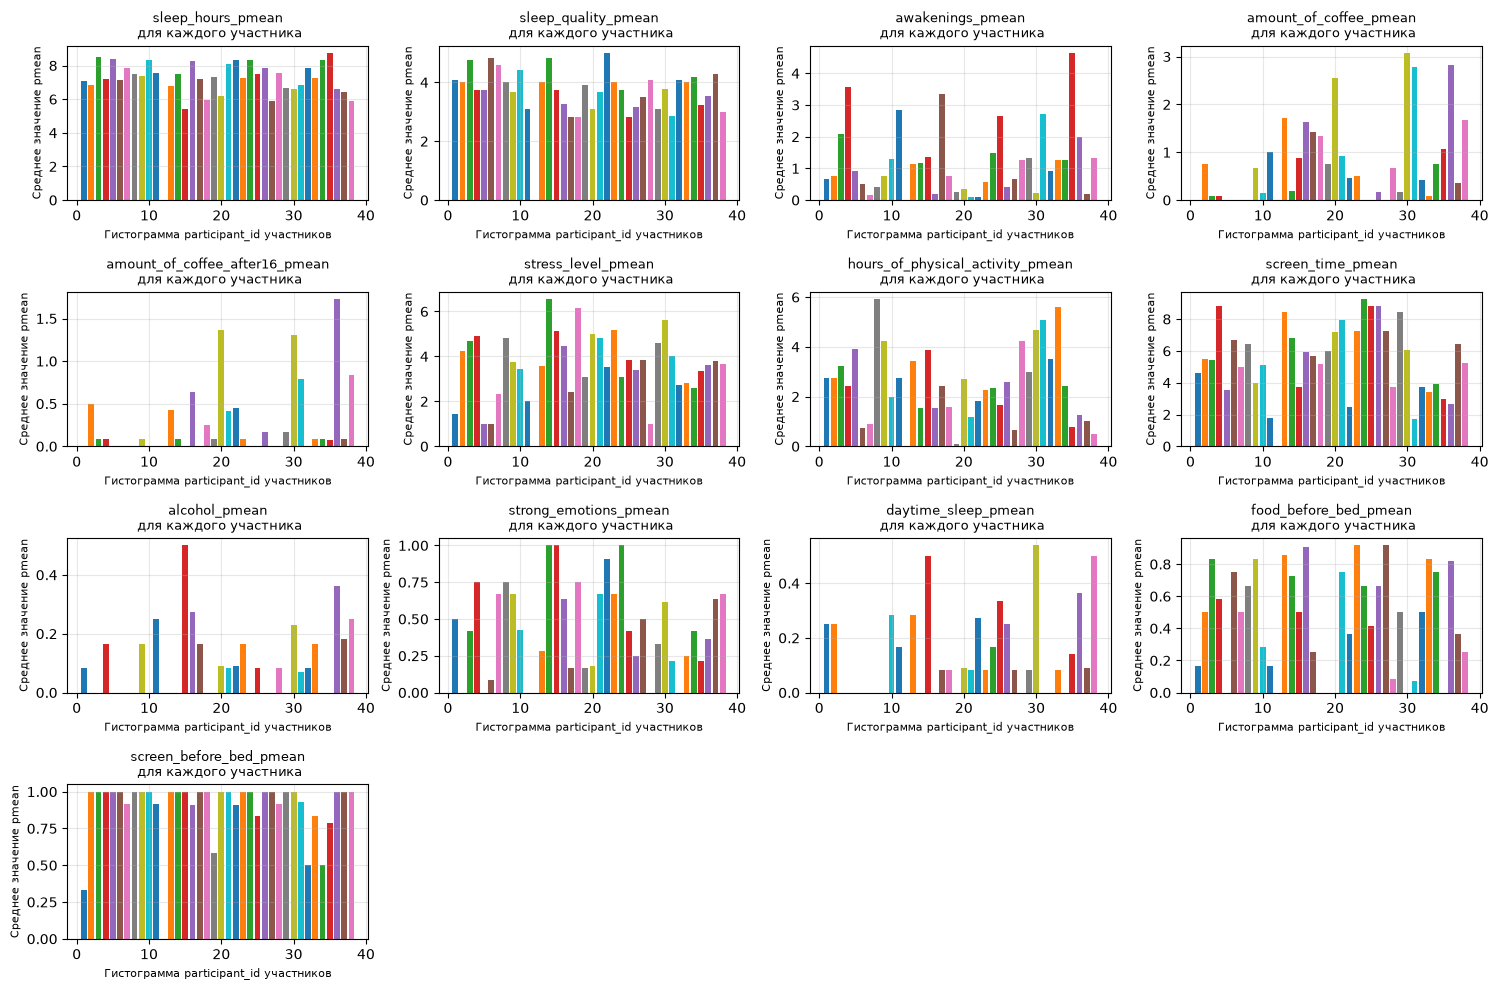

In [57]:
between_cols = [col for col in between_within.columns if "_pmean" in col]

fig, axes = plt.subplots(4, 4, figsize=(15, 10))

for ax, col in zip(axes.flatten(), between_cols):
    for i, group in between_within.groupby(by="participant_id"):
        ax.bar(i, group[col])

    ax.set_title(f"{col}\n для каждого участника", fontsize=9)
    ax.set_xlabel("Гистограмма participant_id участников", fontsize=8)
    ax.set_ylabel("Cреднее значение pmean", fontsize=8)
    
    ax.grid(True, alpha=0.3)
    
for ax in axes.flatten()[len(between_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Анализ индивидуальных средних значений признаков показал наличие существенных различий между участниками по ряду характеристик. Наиболее выраженная межличностная неоднородность наблюдается для количества пробуждений, употребления кофе, уровня стресса, физической активности и экранного времени. В то же время для алкоголя и дневного сна значения у большинства участников близки к нулю, что указывает на низкую распространённость этих характеристик в выборке.

### Визуализация внутриличностной декомпозиции (with_in)

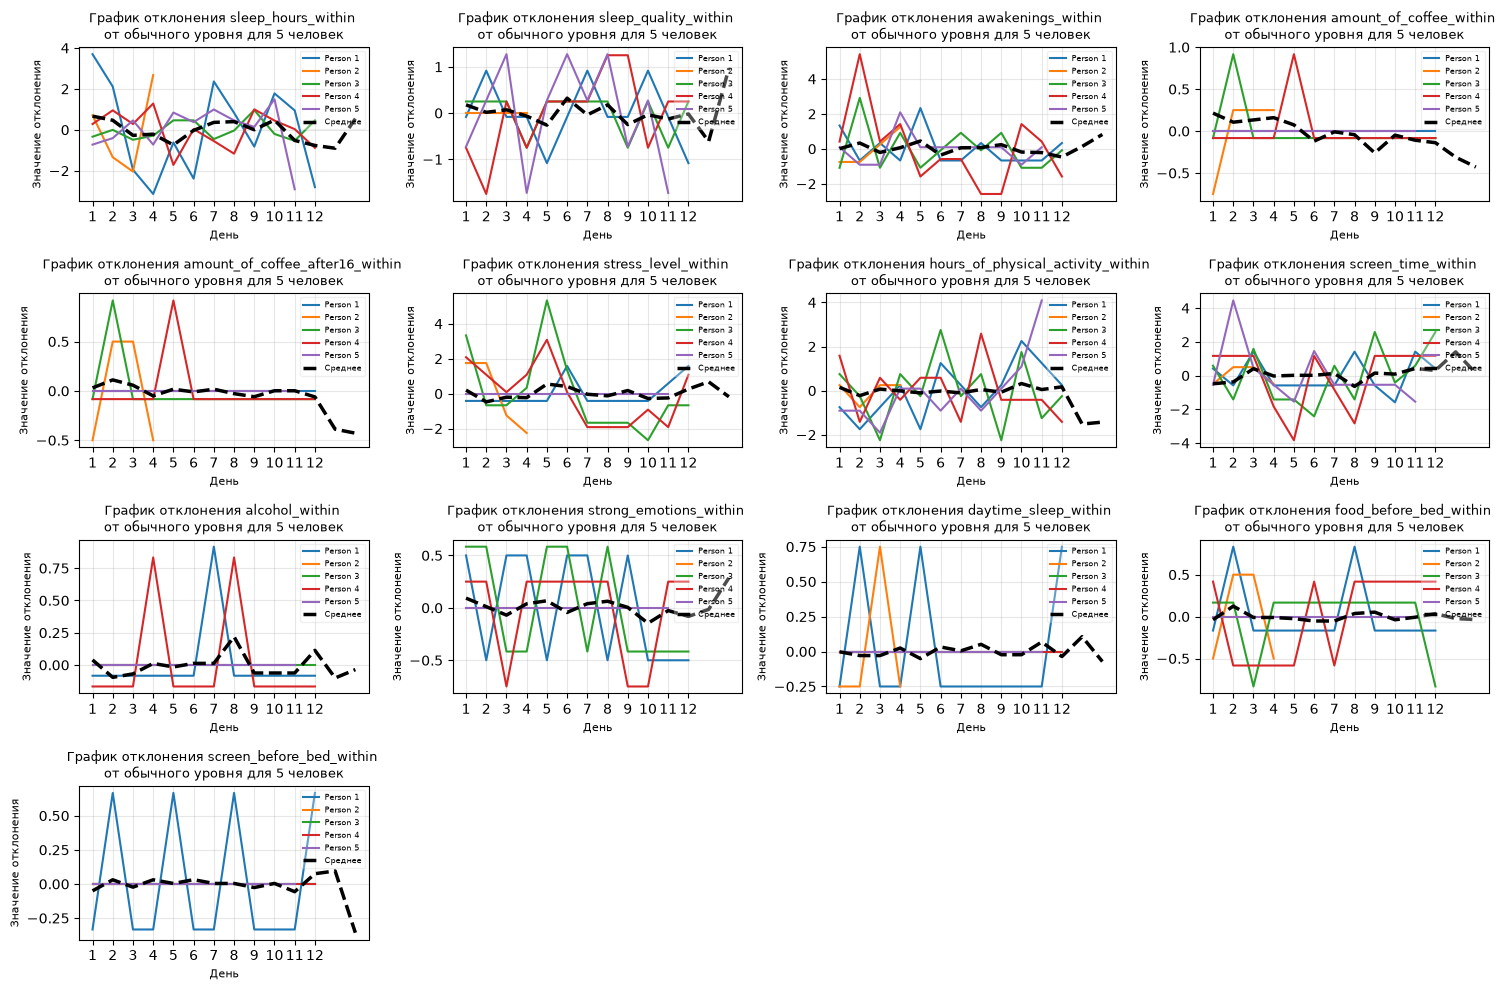

In [58]:
people = sorted(between_within['participant_id'].unique())[:5]

fig, axes = plt.subplots(4, 4, figsize=(15, 10))

for ax, col in zip(axes.flatten(), with_in_cols):
    for person in people:
        days_person = between_within[between_within["participant_id"] == person]["observation_number"].values
        col_person = between_within[between_within["participant_id"] == person][col].values
        ax.plot(days_person, col_person, label=f"Person {person}")
        
    mean_line = between_within.groupby('observation_number')[col].mean()
    ax.plot(mean_line.index, mean_line.values,color='black', lw=2.5, linestyle='--', label='Среднее')
    
    ax.set_title(f"График отклонения {col} \nот обычного уровня для 5 человек", fontsize=9)
    ax.set_xticks(range(1, 13, 1))
    ax.set_xlabel('День', fontsize=8)
    ax.set_ylabel('Значение отклонения', fontsize=8)
    
    ax.legend(fontsize=5.5, loc='upper right', framealpha=0.3)
    
    ax.grid(True, alpha=0.3)

    
for ax in axes.flatten()[len(with_in_cols):]:       
        ax.axis("off")
        
plt.tight_layout()
plt.show()

Графики подтверждают наличие выраженной внутриличностной вариативности для ряда признаков. Особенно заметны изменения продолжительности и качества сна, уровня стресса, физической активности и количества пробуждений. Это подтверждает целесообразность использования within-компонентов признаков для дальнейшего анализа связи между изменениями состояния человека и вероятностью запоминания сновидения.

### Подсчёт долей within и between

In [59]:
share_variance = pd.DataFrame()

for i in time_varying_cols:
    total_variance = np.var(df[i])
    between_variance = np.var(between_within[f"{i}_pmean"])
    within_variance = np.var(between_within[f"{i}_within"])

    share_variance.loc[i, "total_variance"] = total_variance
    share_variance.loc[i, "between_share"] = between_variance / (between_variance + within_variance)
    share_variance.loc[i, "within_share"] = within_variance / (between_variance + within_variance)

share_variance

,total_variance,between_share,within_share
sleep_hours,3.024110,0.221112,0.778888
sleep_quality,1.138639,0.324776,0.675224
awakenings,2.731088,0.461393,0.538607
amount_of_coffee,1.249949,0.640104,0.359896
amount_of_coffee_after16,0.323010,0.563844,0.436156
stress_level,5.249314,0.358098,0.641902
hours_of_physical_activity,3.982874,0.553191,0.446809
screen_time,7.234439,0.620227,0.379773
alcohol,0.086168,0.147987,0.852013
strong_emotions,0.247500,0.351940,0.648060


### Визуализация разложения

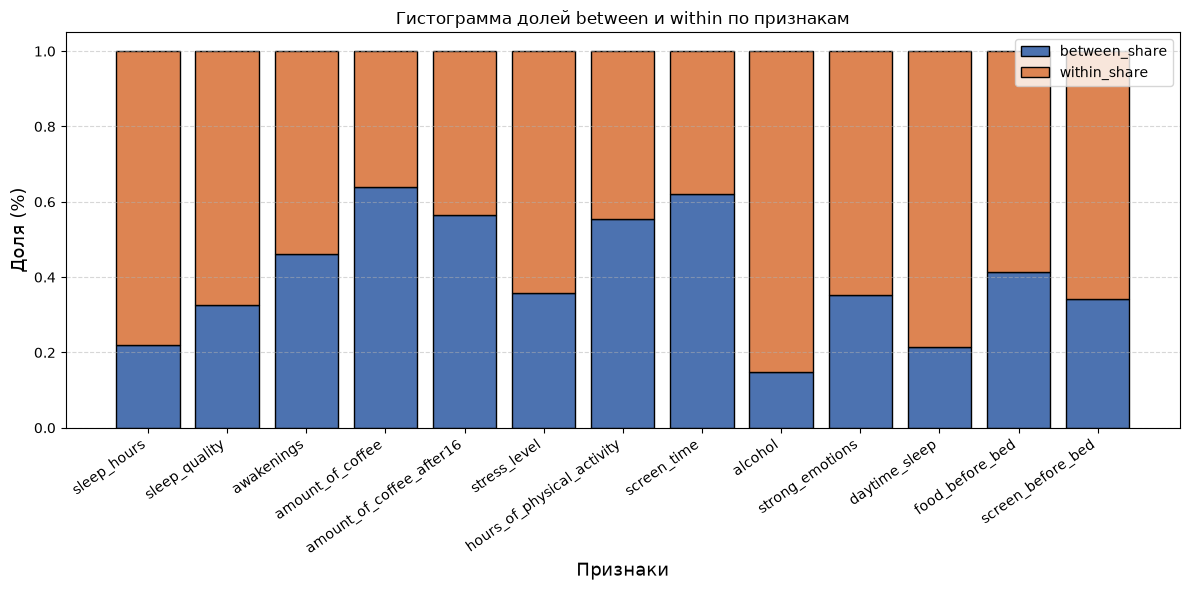

In [60]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(share_variance.index, share_variance["between_share"], color="#4C72B0", edgecolor="black")
ax.bar(share_variance.index, share_variance["within_share"], bottom=share_variance["between_share"], color="#DD8452", edgecolor="black")

ax.set_title("Гистограмма долей between и within по признакам")
ax.set_xlabel('Признаки', fontsize=13)
ax.set_ylabel('Доля (%)', fontsize=13)

ax.set_xticks(range(len(share_variance.index)))
ax.set_xticklabels(share_variance.index, rotation=35, ha='right', fontsize=10)

ax.grid(True, alpha=0.5, axis="y", ls="--")

ax.legend(labels=["between_share", "within_share"])

plt.tight_layout()
plt.show()

### Анализ within- и between-вариации признаков

Для оценки структуры панельных данных была рассчитана доля общей дисперсии каждого признака, обусловленная различиями между участниками `between` и изменениями внутри одного участника от дня к дню `within`.

| Признак                    | Интерпретация|
| ---------------------------| ---------------------------------------------------------------------------- |
| sleep_hours                | Признак сильно меняется у одного человека от дня к дню                       |
| sleep_quality              | Преобладает внутриличностная вариативность                                   |
| awakenings                 | Вариативность примерно одинаковая обусловлена различиями между людьми и днями|
| amount_of_coffee           | Сильнее характеризует индивидуальные привычки                                |
| amount_of_coffee_after16   | Небольшое преимущество межличностных различий                                |
| stress_level               | Стресс заметно меняется у одного человека от дня к дню                       |
| hours_of_physical_activity | Вариативность умеренно смещена в сторону различий между людьми               |
| screen_time                | Значительная часть различий связана с индивидуальными привычками             |
| alcohol                    | Высокая within-доля, но общая вариативность очень мала                       |
| strong_emotions            | Эмоциональное состояние заметно меняется от дня к дню                        |
| daytime_sleep              | Сильная внутриличностная вариативность                                       |
| food_before_bed            | Умеренно преобладает внутриличностная вариативность                          |
| screen_before_bed          | Признак заметно меняется у одного человека от дня к дню                      |

### Вывод

Анализ показывает, что для ряда признаков значительная часть вариации возникает внутри одного и того же участника, а не только за счёт различий между участниками. Особенно высокая `within`-вариативность наблюдается для `alcohol` (85.2%), `daytime_sleep` (78.7%) и `sleep_hours` (77.9%), а также для `sleep_quality`, `stress_level`, `strong_emotions` и `screen_before_bed`.

Для целей данного исследования это важно, поскольку задача заключается в изучении связи между состоянием и образом жизни человека в предыдущий день и вероятностью запоминания сновидения на следующее утро. Признаки с высокой `within`-вариативностью позволяют анализировать изменения состояния одного и того же человека от дня к дню.

Признаки с высокой `between` долей, например `amount_of_coffee` и `screen_time`, в большей степени отражают устойчивые индивидуальные различия и привычки участников. Поэтому их можно использовать для анализа межличностных различий.

### Визуалиализация с помощью boxplot для 5 участников для признаков с большей within/between декомпозицией

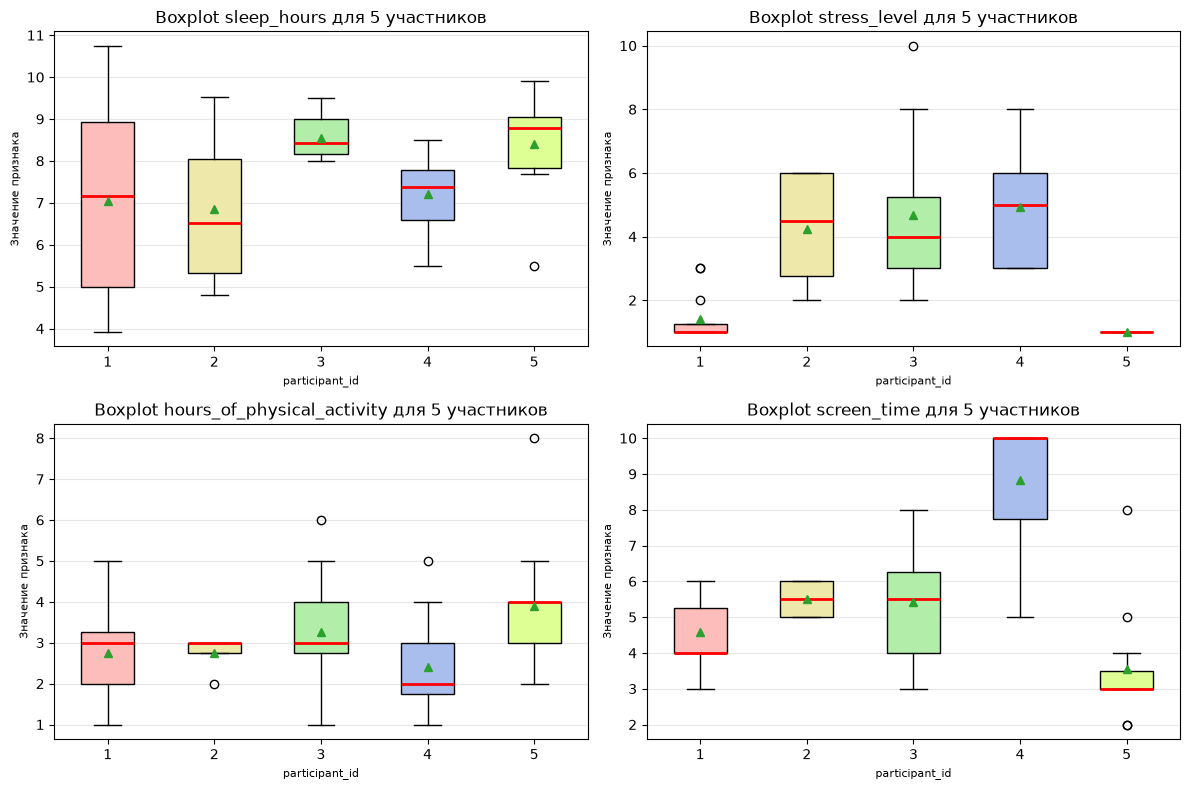

In [61]:
between_within_cols = ["sleep_hours", "stress_level", "hours_of_physical_activity", "screen_time"]
box_colors = ['#fdbdba', "#eee8aa", "#b2eeaa", "#aabeee", "#deff94"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), between_within_cols):
    total_group = []
    for person in people:
        total_group.append(df[df["participant_id"] == person][col].values)
    
    
    ax.set_title(f"Boxplot {col} для 5 участников")
    ax.set_xlabel("participant_id", fontsize=8)
    ax.set_ylabel("Значение признака", fontsize=8)
    
    ax.grid(True, alpha=0.3, axis="y")
    
    bp = ax.boxplot(total_group, patch_artist=True, showmeans=True, medianprops=dict(color="red", lw=2))

    
    for i, color in enumerate(box_colors):
        bp["boxes"][i].set_facecolor(color)
plt.tight_layout()
plt.show()

По графикам видно, что показатели заметно различаются между участниками. Особенно сильно варьируются сон, уровень стресса и экранное время, тогда как физическая активность в большинстве случаев находится примерно в диапазоне 2–4 часов, но также имеет отдельные выбросы.

### Сравнение корреляций между людьми и внутри людей

In [62]:
num_cols_without2 = [col for col in num_cols if col not in ["sex", "dream_remembered"]]

general_matrix = df[num_cols_without2].corr()
within_corr_matrix = between_within[with_in_cols].corr()
between_corr_matrix = between_within[between_cols].corr()

corr_matrix_list = [general_matrix, between_corr_matrix, within_corr_matrix]
corr_matrix_name = ["General матрица", "Between матрица", "Within матрица"]

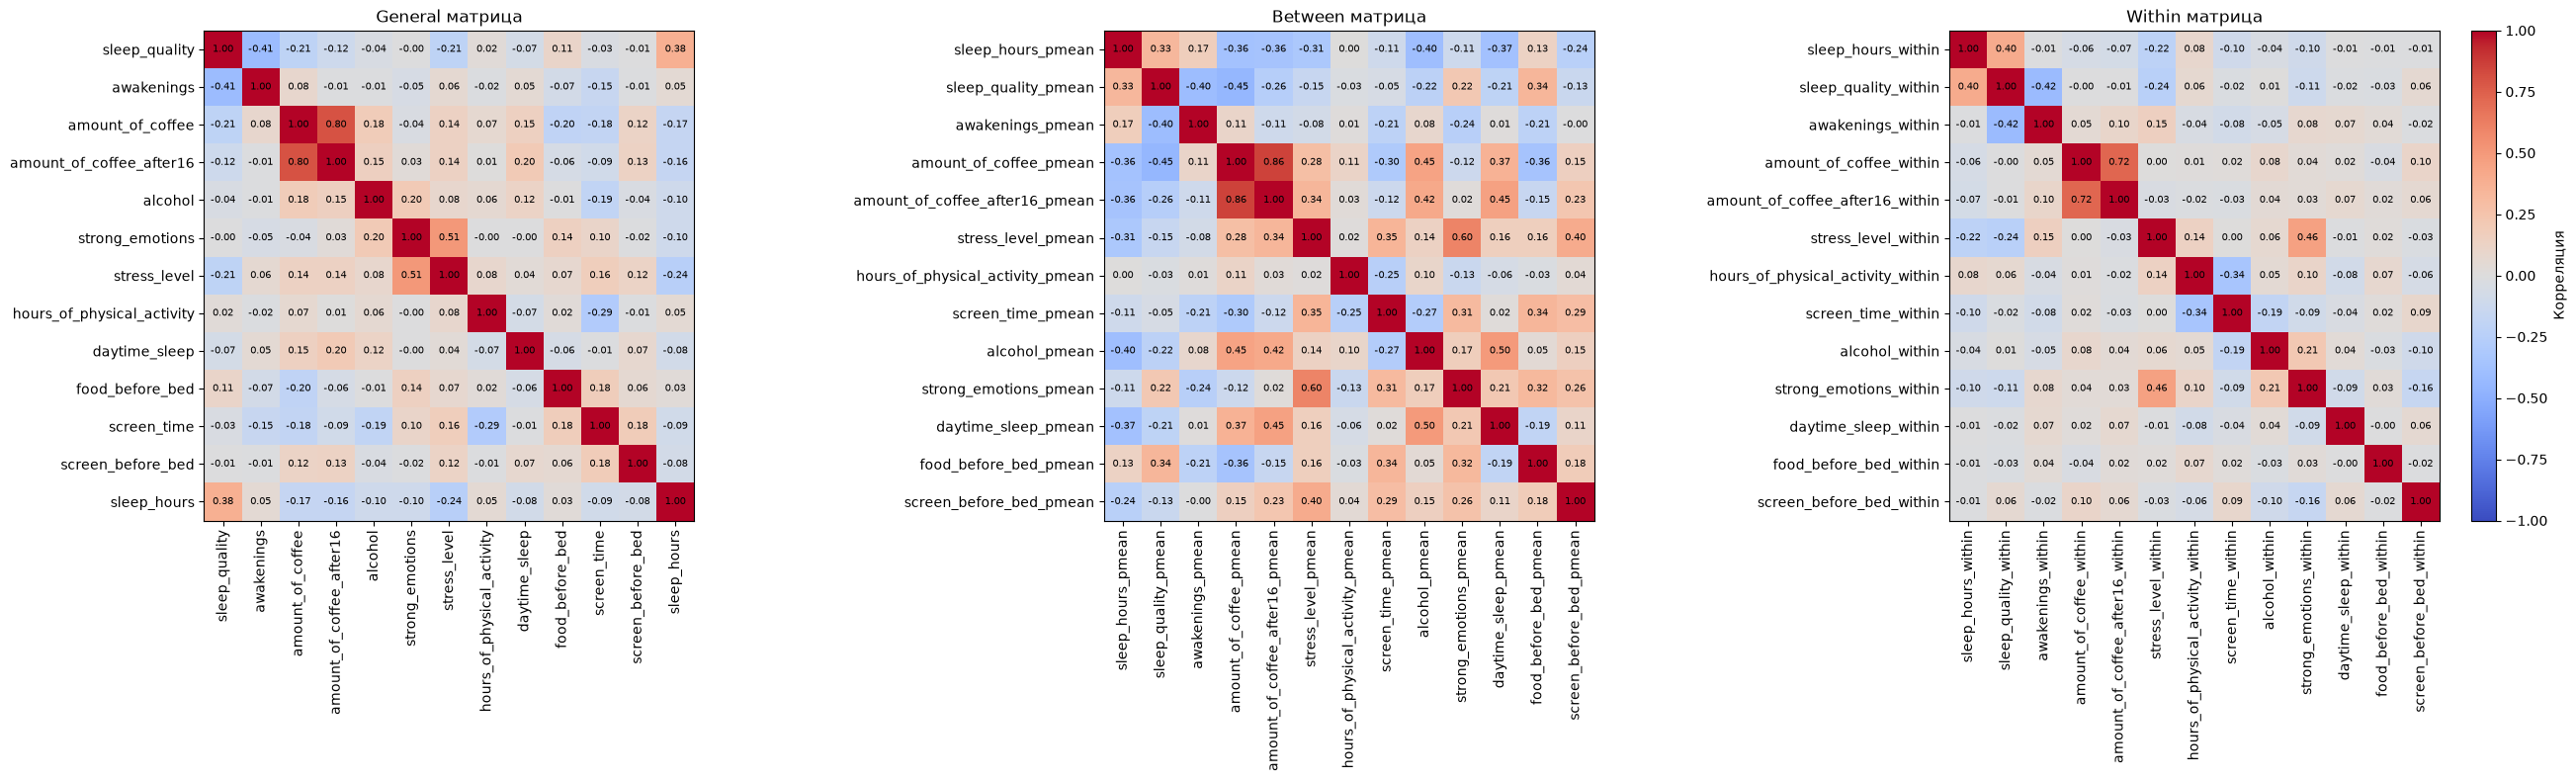

In [63]:
n = len(corr_matrix_list)

fig, axes = plt.subplots(1, n, figsize=(9 * n, 8))

for ax, matrix, name in zip(axes.flatten(), corr_matrix_list, corr_matrix_name):
    
    im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_title(name)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=10)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, fontsize=10, rotation=90)

    for i in range(len(matrix.columns)):
        for j in range(len(matrix.columns)):
            val = matrix.iloc[i, j]
            ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

- Во всех матрицах сохраняется сильная корреляция между признаками amount_of_coffee и amount_of_coffee_after16
- В корреляционной матрице between наблюдает средняя положительная корреляция между strong_emotion_pmean и stress_level_pmean (0.60), alcohol_pmean и daytime_sleep_pmean(0.50), amount_of_coffee(_after16)_pmean и daytime_sleep_pmean(0.45)
- В корреляционной матрице between наблюдает средняя отрицательная корреляция между sleep_quality_pmean и awakenings_pmean (-0.40), alcohol_pmean и sleep_hours_pmean (-0.40), daytime_sleep_mean и sleep_hours_pmean (-0.37)

### Разбор целевой переменной

In [64]:
dream_recall_table = (df.groupby("participant_id").agg(dream_recall_rate=("dream_remembered", "mean"), n_nights=("dream_remembered", "size")).reset_index())

dream_recall_table["dream_recall_rate"] *= 100

dream_recall_table

,participant_id,dream_recall_rate,n_nights
0,1,16.666667,12
1,2,25.000000,4
2,3,41.666667,12
3,4,91.666667,12
4,5,0.000000,11
5,6,50.000000,12
6,7,41.666667,12
7,8,66.666667,12
8,9,41.666667,12
9,10,28.571429,7


In [65]:
dream_recall_table[["dream_recall_rate", "n_nights"]].describe()

,dream_recall_rate,n_nights
count,37.000000,37.000000
mean,43.833756,11.351351
std,21.004741,1.903450
min,0.000000,4.000000
25%,27.272727,11.000000
50%,41.666667,12.000000
75%,58.333333,12.000000
max,91.666667,14.000000


Доля запоминания среди участников варьирует от 0% до 92%, что указывает на выраженные различия между участниками. Это означает, что индивидуальные особенности человека потенциально играют существенную роль в вероятности запоминания сна.

In [66]:
dream_recall_table.loc[dream_recall_table["dream_recall_rate"] == 0]

,participant_id,dream_recall_rate,n_nights
4,5,0.0,11


Участник с participant №5 c 11 записями, единственный не входящий в диапазон от 0 до 100% (невключительно), его within декомпозиция будет равна 0, что следует учесть при дальнейшей работе с внутриличностной декомпозицией

### Проверка корреляции between c целевой переменной `dream_remembered`

In [67]:
between_df = df.groupby(by="participant_id").agg(
    sleep_hours=("sleep_hours", "mean"),
    sleep_quality=("sleep_quality", "mean"),
    awakenings=("awakenings", "mean"),
    stress_level=("stress_level", "mean"),
    hours_of_physical_activity=("hours_of_physical_activity", "mean"),
    screen_time=("screen_time", "mean"),
    strong_emotions=("strong_emotions", "mean"),
    daytime_sleep=("daytime_sleep", "mean"),
    food_before_bed=("food_before_bed", "mean"),
    screen_before_bed=("screen_before_bed", "mean"),
    amount_of_coffee=("amount_of_coffee", "mean"),
    amount_of_coffee_after16=("amount_of_coffee_after16", "mean"),
    alcohol=("alcohol", "mean"),
    dream_mean=("dream_remembered", "mean")
).reset_index(drop=True)

print(f"Размер: {between_df.shape}")
between_df.head(5)

Размер: (37, 14)


,sleep_hours,sleep_quality,awakenings,stress_level,hours_of_physical_activity,screen_time,strong_emotions,daytime_sleep,food_before_bed,screen_before_bed,amount_of_coffee,amount_of_coffee_after16,alcohol,dream_mean
0,7.054167,4.083333,0.666667,1.416667,2.750000,4.583333,0.500000,0.25,0.166667,0.333333,0.000000,0.000000,0.083333,0.166667
1,6.841667,4.000000,0.750000,4.250000,2.750000,5.500000,0.000000,0.25,0.500000,1.000000,0.750000,0.500000,0.000000,0.250000
2,8.537500,4.750000,2.083333,4.666667,3.250000,5.416667,0.416667,0.00,0.833333,1.000000,0.083333,0.083333,0.000000,0.416667
3,7.216667,3.750000,3.583333,4.916667,2.416667,8.833333,0.750000,0.00,0.583333,1.000000,0.083333,0.083333,0.166667,0.916667
4,8.407576,3.727273,0.909091,1.000000,3.909091,3.545455,0.000000,0.00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000


In [68]:
corr_between_target = between_df.corr(method="spearman")
corr_between_target

,sleep_hours,sleep_quality,awakenings,stress_level,hours_of_physical_activity,screen_time,strong_emotions,daytime_sleep,food_before_bed,screen_before_bed,amount_of_coffee,amount_of_coffee_after16,alcohol,dream_mean
sleep_hours,1.000000,0.309201,0.046622,-0.383895,0.005101,-0.162792,-0.081540,-0.360626,0.084465,-0.381912,-0.325093,-0.333823,-0.343088,-0.081107
sleep_quality,0.309201,1.000000,-0.347855,-0.190779,0.012420,-0.087587,0.133246,-0.231612,0.261526,-0.124232,-0.409582,-0.210075,-0.240182,-0.259004
awakenings,0.046622,-0.347855,1.000000,-0.107993,0.187596,-0.205151,-0.191931,0.102736,-0.093991,-0.020667,0.074855,-0.228528,0.058137,0.446650
stress_level,-0.383895,-0.190779,-0.107993,1.000000,0.028478,0.383780,0.550574,0.125781,0.160177,0.486047,0.276672,0.512843,0.153400,0.196977
hours_of_physical_activity,0.005101,0.012420,0.187596,0.028478,1.000000,-0.239008,-0.196073,-0.082889,-0.046811,0.017325,0.019203,-0.068783,0.094484,0.007680
screen_time,-0.162792,-0.087587,-0.205151,0.383780,-0.239008,1.000000,0.270202,0.052644,0.320155,0.460154,-0.260901,0.057826,-0.244893,0.229804
strong_emotions,-0.081540,0.133246,-0.191931,0.550574,-0.196073,0.270202,1.000000,0.123638,0.289178,0.274900,-0.139167,0.102788,0.142939,0.195176
daytime_sleep,-0.360626,-0.231612,0.102736,0.125781,-0.082889,0.052644,0.123638,1.000000,-0.174369,0.171623,0.286032,0.241540,0.319599,-0.035809
food_before_bed,0.084465,0.261526,-0.093991,0.160177,-0.046811,0.320155,0.289178,-0.174369,1.000000,0.206278,-0.240558,0.017320,-0.002512,0.381536
screen_before_bed,-0.381912,-0.124232,-0.020667,0.486047,0.017325,0.460154,0.274900,0.171623,0.206278,1.000000,0.047760,0.219272,-0.029713,0.146041


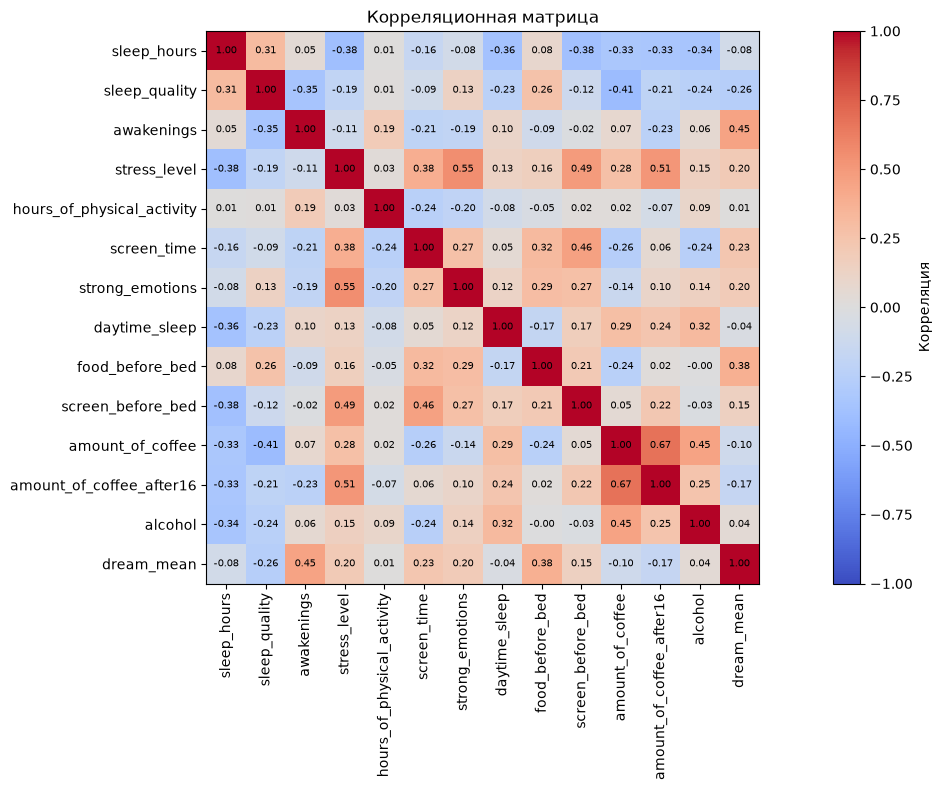

In [69]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(corr_between_target, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title("Корреляционная матрица")
ax.set_yticks(range(len(corr_between_target.columns)))
ax.set_yticklabels(corr_between_target.columns, fontsize=10, rotation=0)
ax.set_xticks(range(len(corr_between_target.columns)))
ax.set_xticklabels(corr_between_target.columns, fontsize=10, rotation=90)

for i in range(len(corr_between_target.columns)):
    for j in range(len(corr_between_target.columns)):
        val = corr_between_target.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

- У участников, которые в среднем чаще просыпаются ночью, наблюдается тенденция к большей доле запоминания снов.
- У участников, которые чаще едят перед сном, наблюдается тенденция к большей средней доле запоминания снов.
- Люди с большей средней продолжительностью экранного времени имеют несколько более высокую долю запоминания снов.
- У участников с более высокой средней субъективной оценкой качества сна доля запоминания снов несколько ниже.

### Проверка корреляции within c целевой переменной `dream_remembered`

In [70]:
df["dream_recall_rate"] = df.groupby("participant_id")["dream_remembered"].transform("mean")

between_within["dream_remembered_within"] = df["dream_remembered"] - df["dream_recall_rate"]
between_within = between_within[between_within["participant_id"] != 5]

In [71]:
with_in_cols.append("dream_remembered_within")

corr_within_target = between_within[with_in_cols].corr(method="spearman")
corr_within_target

,sleep_hours_within,sleep_quality_within,awakenings_within,amount_of_coffee_within,amount_of_coffee_after16_within,stress_level_within,hours_of_physical_activity_within,screen_time_within,alcohol_within,strong_emotions_within,daytime_sleep_within,food_before_bed_within,screen_before_bed_within,dream_remembered_within
sleep_hours_within,1.000000,0.366166,0.133832,-0.092581,-0.063191,-0.207363,0.070233,-0.065519,-0.031845,-0.116446,-0.029012,-0.018271,-0.011005,0.161556
sleep_quality_within,0.366166,1.000000,-0.330737,-0.055982,-0.020004,-0.204739,0.079454,-0.028527,0.014786,-0.123172,0.009901,-0.020016,0.034946,0.112870
awakenings_within,0.133832,-0.330737,1.000000,0.081159,0.006567,0.049512,-0.047551,-0.119345,-0.019990,0.021703,0.090192,0.038877,0.008835,0.045847
amount_of_coffee_within,-0.092581,-0.055982,0.081159,1.000000,0.580396,-0.001918,0.013237,0.077338,0.018235,-0.015763,0.013465,-0.072761,0.121714,-0.035933
amount_of_coffee_after16_within,-0.063191,-0.020004,0.006567,0.580396,1.000000,-0.039489,-0.013784,-0.029871,0.002874,-0.004213,0.030241,-0.023079,0.081546,-0.063843
stress_level_within,-0.207363,-0.204739,0.049512,-0.001918,-0.039489,1.000000,0.142602,0.021698,0.076179,0.465406,-0.004042,0.033572,-0.020529,-0.025953
hours_of_physical_activity_within,0.070233,0.079454,-0.047551,0.013237,-0.013784,0.142602,1.000000,-0.234786,0.041625,0.112646,-0.056584,0.066352,-0.074658,0.056638
screen_time_within,-0.065519,-0.028527,-0.119345,0.077338,-0.029871,0.021698,-0.234786,1.000000,-0.125124,-0.091618,-0.042677,0.031218,0.067053,-0.018803
alcohol_within,-0.031845,0.014786,-0.019990,0.018235,0.002874,0.076179,0.041625,-0.125124,1.000000,0.135035,0.068217,0.019629,-0.112935,0.008166
strong_emotions_within,-0.116446,-0.123172,0.021703,-0.015763,-0.004213,0.465406,0.112646,-0.091618,0.135035,1.000000,-0.067844,0.020870,-0.128170,0.013037


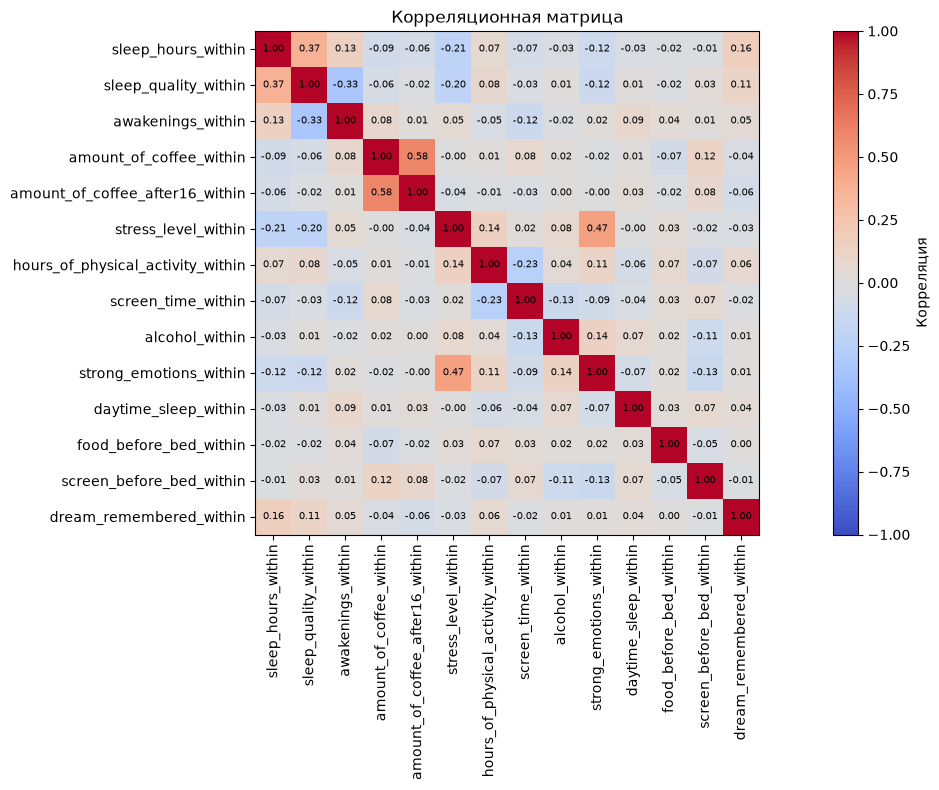

In [72]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(corr_within_target, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title("Корреляционная матрица")
ax.set_yticks(range(len(corr_within_target.columns)))
ax.set_yticklabels(corr_within_target.columns, fontsize=10, rotation=0)
ax.set_xticks(range(len(corr_within_target.columns)))
ax.set_xticklabels(corr_within_target.columns, fontsize=10, rotation=90)

for i in range(len(corr_within_target.columns)):
    for j in range(len(corr_within_target.columns)):
        val = corr_within_target.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

Внутри участников есть небольшая положительная тенденция: в ночи, когда человек спал дольше своего обычного уровня, вероятность запоминания сна также была несколько выше его обычного уровня.

### Таблицу решений по признакам для первой модели

|Признак|Наблюдаемая структура|Решение для первой модели|Обоснование|
|-------|---------------------|-------------------------|-----------|
|age|Constant, только between|raw (для baseline)|Признак не меняется внутри участника, поэтому разложение на within/between невозможно (используется как индивидуальная характеристика участника)|
|sex|Constant, только between|raw (для baseline)|Признак постоянен для участника и представляет межличностное различие|
|sleep_hours|Сильно преобладает within-вариативность (=78%). Between-связь с `dream_mean` слабая (`r = -0.08`), within-связь слабая положительная (`r = 0.16`)|raw (для baseline)|Признак сильно меняется от ночи к ночи, однако явной сильной связи с target ни на одном уровне не обнаружено|
|sleep_quality|Преобладает within-вариативность. Between-связь слабая отрицательная (`r = -0.26`), within-связь слабая положительная (`r = 0.11`)|raw (для baseline)|Наблюдаются слабые разнонаправленные тенденции, поэтому разделение на компоненты пока не даёт достаточно убедочного основания|
|awakenings|Within и between-вариация сопоставимы. Наиболее заметная between-связь с target (`r = 0.45`), within-связь слабая (`rₛ ≈ 0.05`)|raw (для baseline)|Связь преимущественно отражает различия между участниками: люди, которые в среднем чаще просыпаются, имеют тенденцию чаще запоминать сны|
|amount_of_coffee|Значительная between-вариативность; сильно коррелирует с `amount_of_coffee_after16`|raw (для baseline)|Признак отражает индивидуальные привычки, но использование одновременно двух показателей кофе создаёт избыточную информацию|
|amount_of_coffee_after16|Значительная between-вариативность; сильно коррелирует с общим количеством кофе|exclude|Информация частично содержится в `amount_of_coffee`|
|stress_level|Значительная within-вариативность. Between-связь слабая положительная (`r = 0.20`), within-связь практически отсутствует (`r = -0.03`)|raw (для baseline)|Исходный признак оставлен для простой baseline-модели; его коэффициент нельзя интерпретировать отдельно как within- или between-эффект.|
|hours_of_physical_activity|Умеренная between-вариативность. Связь с target практически отсутствует (`r = 0.01` between; `= 0.06` within)|raw (для baseline)|Признак не показывает заметной связи с target, но его можно сохранить как потенциальный предиктор для baseline-модели|
|screen_time|Значительная between-вариативность. Between-связь слабая положительная (`r = 0.23`), within-связь практически отсутствует (`r = -0.02`)|raw (для baseline)|Наблюдаемая тенденция преимущественно относится к различиям между участниками, а не к изменениям экранного времени относительно собственного среднего|
|alcohol|Очень высокая within-доля, но низкая общая распространённость события|exclude|Высокая within-доля обусловлена редкостью признака, а не обязательно содержательной внутриличностной вариативностью|
|strong_emotions|Высокая within-вариативность. Between-связь слабая положительная (`r = 0.20`), within-связь практически отсутствует (`r = 0.01`)|raw (для baseline)|Эмоциональное состояние меняется от дня к дню, однако выраженной связи с target не обнаружено. Сохраняем для baseline, не выделяя отдельный within-компонент|
|daytime_sleep|Высокая within-доля (=79%), но событие относительно редкое. Between-связь практически отсутствует (`r = -0.04`), within-связь очень слабая (`= 0.04`)|raw (для baseline)|Высокая within-доля сама по себе не является доказательством полезности признака, оставить как исходный бинарный признак для baseline|
|food_before_bed|Умеренно преобладает within-вариативность. Between-связь заметная (`r = 0.38`), within-связь практически отсутствует (`r = 0.00`)|raw (для baseline)|Связь наблюдается преимущественно между участниками, а не при изменении поведения относительно собственной нормы. Для нового пользователя без истории доступен только raw.|
|screen_before_bed|Значительная within-вариативность. Between-связь слабая (`r = 0.15`), within-связь практически отсутствует (`= -0.01`)|raw (для baseline)|Признак меняется внутри человека, но явной связи с target не показывает|
